In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

df_master = pd.read_csv("../data/processed/master_data.csv")
df_master['order_purchase_timestamp'] = pd.to_datetime(df_master['order_purchase_timestamp'])
df_master['order_delivered_customer_date'] = pd.to_datetime(df_master['order_delivered_customer_date'])
df_master['order_estimated_delivery_date'] = pd.to_datetime(df_master['order_estimated_delivery_date'])
print("Loaded:", df_master.shape)

Loaded: (118434, 23)


In [2]:
delivered = df_master[df_master['order_status'] == 'delivered'].copy()

delivered['delivery_delay_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_estimated_delivery_date']
).dt.days

# Seller-level aggregation
seller_stats = delivered.groupby('seller_id').agg(
    avg_delay     = ('delivery_delay_days', 'mean'),
    total_orders  = ('order_id', 'nunique'),
    avg_price     = ('price', 'mean'),
    total_revenue = ('payment_value', 'sum')
).reset_index().dropna()

print("Seller stats shape:", seller_stats.shape)
print(seller_stats.describe())

Seller stats shape: (2970, 5)
         avg_delay  total_orders    avg_price  total_revenue
count  2970.000000   2970.000000  2970.000000    2970.000000
mean    -12.311008     32.935690   177.801911    6658.639879
std       8.013005    105.407111   346.254245   21669.564634
min     -66.000000      1.000000     6.000000      15.220000
25%     -15.482069      2.000000    52.306477     328.205000
50%     -12.000000      7.000000    94.989273    1302.500000
75%      -9.014706     22.000000   171.676250    5059.900000
max     167.000000   1819.000000  6735.000000  505437.160000


In [3]:
features = ['avg_delay','total_orders','avg_price','total_revenue']
X = seller_stats[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(contamination=0.05, random_state=42)
seller_stats['anomaly'] = iso.fit_predict(X_scaled)
seller_stats['anomaly_label'] = seller_stats['anomaly'].map({1:'Normal', -1:'Anomaly'})

anomalies = seller_stats[seller_stats['anomaly'] == -1]
print(f"Total sellers: {len(seller_stats)}")
print(f"Anomalies detected: {len(anomalies)}")
print(f"\nTop anomalous sellers:")
print(anomalies[['seller_id','avg_delay','total_orders','total_revenue']].head(10))

Total sellers: 2970
Anomalies detected: 149

Top anomalous sellers:
                            seller_id  avg_delay  total_orders  total_revenue
1    001cca7ae9ae17fb1caed9dfb1094831 -13.237288           195       47557.95
24   0241d4d5d36f10f80c644447315af0bd -12.984733           238       42183.60
40   039e6ad9dae79614493083e241147386 -12.200000             5       13273.42
45   04308b1ee57b6625f47df1d56f00eedf -11.576087            92       61940.62
70   05feb94f19d094d4b0f9281f0b1d4c99 -12.285714             6       10050.04
79   06a2c3af7b3aee5d69171b0e14f0ee87 -11.187192           389       51602.28
144  0b90b6df587eb83608a64ea8b390cf07 -18.323810           163       51350.29
170  0ea22c1cfbdc755f86b9b54b39c16043 -16.894161           234       20382.06
188  1025f0e2d44d7041d6cf58b6550e0bfa -11.100413           910      306000.35
209  128639473a139ac0f3e5f5ade55873a5 -12.419014           527       24235.79


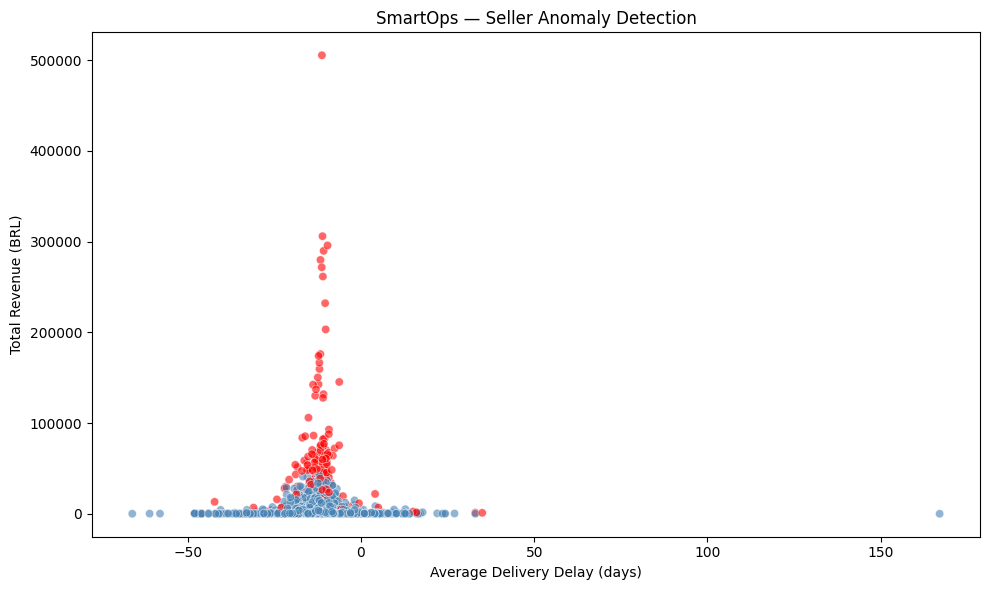

Anomaly chart saved!


In [4]:
colors = seller_stats['anomaly'].map({1:'steelblue', -1:'red'})

plt.figure(figsize=(10, 6))
plt.scatter(seller_stats['avg_delay'], 
            seller_stats['total_revenue'],
            c=colors, alpha=0.6, edgecolors='white', linewidth=0.5)
plt.title('SmartOps — Seller Anomaly Detection')
plt.xlabel('Average Delivery Delay (days)')
plt.ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig('../outputs/anomaly_detection.png')
plt.show()
print("Anomaly chart saved!")

In [5]:
seller_stats.to_csv('../data/processed/seller_anomalies.csv', index=False)

print("=== Module 3 Summary ===")
print(f"Total sellers analysed: {len(seller_stats):,}")
print(f"Anomalous sellers flagged: {len(anomalies):,}")
print(f"Anomaly rate: {len(anomalies)/len(seller_stats)*100:.1f}%")
print(f"\nWorst delay anomaly: {anomalies['avg_delay'].max():.1f} days")
print(f"Highest revenue anomaly: R${anomalies['total_revenue'].max():,.2f}")
print("\nModule 3 Complete!")

=== Module 3 Summary ===
Total sellers analysed: 2,970
Anomalous sellers flagged: 149
Anomaly rate: 5.0%

Worst delay anomaly: 35.0 days
Highest revenue anomaly: R$505,437.16

Module 3 Complete!
